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


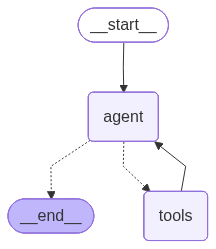


FINAL EXECUTION
================================ Human Message =================================


Give me one recent Agentic AI development.
Then add 10 and 20.
Then multiply 30 by 15.
Do everything step-by-step.

================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_p3v1RRdEtrpxSjJuC0NsCqEH)
 Call ID: call_p3v1RRdEtrpxSjJuC0NsCqEH
  Args:
    query: recent Agentic AI development
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Top 11 Agentic AI Trends to Watch in 2026", "url": "https://www.firecrawl.dev/blog/agentic-ai-trends", "content": "### 8. Small language models are proving enterprise-ready\n\nSLMs (Small Language Models) are gaining traction as organizations realize bigger isn't always better. Models like Microsoft's Phi-4, Google's Gemini Nano, Meta's Llama 3.2, Hugging Face's SmolLM, and Alibaba's Qwen2.5 are demonstrating t

In [2]:
"""
=============================================================
FILE 4 — ITERATIVE REACT AGENT
=============================================================

CONCEPTS TAUGHT:
-----------------
1. ReAct pattern
2. Cyclic graphs
3. Iterative reasoning
4. Tool chaining
5. Multi-step planning
6. Observe -> Think -> Act loop
7. Real agent architecture
8. Agent memory accumulation
9. Streaming execution
10. Multi-tool sequential usage

KEY IDEA:
---------
A TRUE agent is a cyclic graph.

LLM -> Tools -> LLM -> Tools -> ...

"""

# =============================================================
# STEP 1 — IMPORTS
# =============================================================

import os
from dotenv import load_dotenv

load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

print(os.getenv("TAVILY_API_KEY"))

# =============================================================
# STEP 2 — TOOLS
# =============================================================

from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.tools.tavily_search import TavilySearchResults

wikipedia = WikipediaQueryRun(
    api_wrapper=WikipediaAPIWrapper()
)

web_search = TavilySearchResults(max_results=2)



def my_add(a: int, b: int) -> int:
    """Add two integers"""
    return a + b



def my_mult(a: int, b: int) -> int:
    """Multiply two integers"""
    return a * b

TOOLS = [
    wikipedia,
    web_search,
    my_add,
    my_mult,
]


# =============================================================
# STEP 3 — LLM
# =============================================================

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")

llm_with_tools = llm.bind_tools(TOOLS)

# =============================================================
# STEP 4 — STATE
# =============================================================

from typing_extensions import TypedDict
from typing import Annotated
from langgraph.graph.message import add_messages


class State(TypedDict):
    messages: Annotated[list, add_messages]

# =============================================================
# STEP 5 — AGENT NODE
# =============================================================
# The agent can:
# - reason
# - call tools
# - observe results
# - reason again


def agent(state: State):

    response = llm_with_tools.invoke(state["messages"])

    return {
        "messages": [response]
    }

# =============================================================
# STEP 6 — BUILD CYCLIC GRAPH
# =============================================================

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

workflow = StateGraph(State)

workflow.add_node("agent", agent)
workflow.add_node("tools", ToolNode(TOOLS))

workflow.add_edge(START, "agent")


# =============================================================
# CONDITIONAL TOOL ROUTING
# =============================================================

workflow.add_conditional_edges(
    "agent",
    tools_condition,
)

# =============================================================
# TRUE AGENT LOOP
# =============================================================
# THIS IS THE MOST IMPORTANT CONCEPT.
#
# tools -> agent creates:
#
# THINK -> ACT -> OBSERVE -> THINK AGAIN
#
# This enables:
# - Multiple tool calls
# - Sequential reasoning
# - ReAct agents
# - Planning

workflow.add_edge("tools", "agent")

workflow.add_edge("agent", END)

app = workflow.compile()

# =============================================================
# STEP 7 — VISUALIZE GRAPH
# =============================================================

from IPython.display import Image, display


display(Image(app.get_graph().draw_mermaid_png()))

# =============================================================
# STEP 8 — TEST MULTI-STEP AGENT
# =============================================================

from langchain_core.messages import HumanMessage

query = """
Give me one recent Agentic AI development.
Then add 10 and 20.
Then multiply 30 by 15.
Do everything step-by-step.
"""


result = app.invoke(
    {
        "messages": [HumanMessage(content=query)]
    }
)


print("\nFINAL EXECUTION")

for m in result["messages"]:
    m.pretty_print()


# =============================================================
# STEP 9 — STREAM EXECUTION
# =============================================================
# stream() helps us observe agent reasoning.

print("\nSTREAMING AGENT EXECUTION")

for event in app.stream(
    {
        "messages": [
            HumanMessage(content=query)
        ]
    }
):
    print(event)
